# All-studies plots — one `utils`, every study → `plots_study/<study>/`

Generates the most important per-study plots for all three studies using the **same**
`StudyResults` class (study_v2_cat's, whose loader reads both `.npz` and `.mat`), and saves
each study's figures to `plots_study/<study>/`.

| study dir | model |
|---|---|
| `study_v2` | LVGP (MATLAB, `.mat`) |
| `study_v2_gp` | per-category GP (`.npz`) |
| `study_v2_cat` | categorical GP / Method C (`.npz`) |

**Kernel: ml_gp_env.** Run after each study's sweep exists (studies with no results are skipped).

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os, sys, glob
sys.path.insert(0, os.path.abspath("study_v2_cat"))   # ONE utils for all (dual .npz/.mat loader)
%matplotlib inline
import matplotlib.pyplot as plt
from utils import StudyResults

STUDIES = [("study_v2", "LVGP"), ("study_v2_gp", "Per-category GP"), ("study_v2_cat", "Categorical GP")]
OUT = "plots_study"

def key_plots(s):
    """(filename, fig-maker) for the most important per-study plots (all is_ground_truth=True)."""
    sr = None                                            # single-run example: ei/nrep10/seed01.*
    for ext in ("npz", "mat"):
        if glob.glob(os.path.join(s.results_dir, "ei", "nrep10", f"seed01.{ext}")):
            sr = f"ei/nrep10/seed01.{ext}"; break
    plots = [
        ("0_progress",                lambda: s.plot_progress()),
        ("1_convergence_true_log",    lambda: s.plot_convergence_true(log=True)),
        ("2_simple_regret_true",      lambda: s.plot_simple_regret(is_ground_truth=True)),
        ("3_input_space",             lambda: s.plot_input_space(n_rep=10)),
        ("4_objective_variance_true", lambda: s.plot_objective_variance(is_ground_truth=True)),  # aggregated = matches heatmap
        ("5_summary_heatmaps_true",   lambda: s.plot_summary_heatmaps(is_ground_truth=True)),
        ("6_best_per_category_true",  lambda: s.plot_best_per_category(n_rep=10, is_ground_truth=True)),
        ("7_final_boxplots_true",     lambda: s.plot_final_boxplots(is_ground_truth=True)),
        ("8_level_histogram",         lambda: s.plot_level_histogram()),
        ("9_runtime",                 lambda: s.plot_runtime()),
    ]
    if sr:
        plots.append(("10_single_run_ei", lambda: s.plot_single_run(sr)))
    return plots

def generate(sdir, label):
    s = StudyResults.load(os.path.join(sdir, "results"))
    if not s.runs:
        print(f"  {sdir}: no runs yet — skipped"); return s
    outdir = os.path.join(OUT, sdir); os.makedirs(outdir, exist_ok=True)
    print(f"{sdir} ({label}): {len(s.runs)} runs -> {outdir}/")
    for name, fn in key_plots(s):
        try:
            fig = fn(); fig.savefig(os.path.join(outdir, name + ".png"), dpi=140, bbox_inches="tight"); plt.close(fig)
            print(f"    saved {name}.png")
        except Exception as e:
            print(f"    skip  {name}: {type(e).__name__}: {e}")
    return s

## Generate + save all studies

In [2]:
studies = {sdir: generate(sdir, label) for sdir, label in STUDIES}
print("\ndone — browse plots_study/<study>/")

study_v2 (LVGP): 1080 runs -> plots_study/study_v2/
    saved 0_progress.png
    saved 1_convergence_true_log.png
    saved 2_simple_regret_true.png
    saved 3_input_space.png
    saved 4_objective_variance_true.png
    saved 5_summary_heatmaps_true.png
    saved 6_best_per_category_true.png
    saved 7_final_boxplots_true.png
    saved 8_level_histogram.png
    saved 9_runtime.png
    saved 10_single_run_ei.png
study_v2_gp (Per-category GP): 1080 runs -> plots_study/study_v2_gp/
    saved 0_progress.png
    saved 1_convergence_true_log.png
    saved 2_simple_regret_true.png
    saved 3_input_space.png
    saved 4_objective_variance_true.png
    saved 5_summary_heatmaps_true.png
    saved 6_best_per_category_true.png
    saved 7_final_boxplots_true.png
    saved 8_level_histogram.png
    saved 9_runtime.png
    saved 10_single_run_ei.png
study_v2_cat (Categorical GP): 1080 runs -> plots_study/study_v2_cat/
    saved 0_progress.png
    saved 1_convergence_true_log.png
    saved 2_simpl

## Inline preview
Set `which` to any study to view a couple of its plots inline. The objective–variance scatter
is now **aggregated** (mean per acq×n_rep) so it matches the summary heatmap's σ² range; pass
`aggregate=False` to see the per-seed cloud (a few n_rep=3 outliers reach much higher σ²).

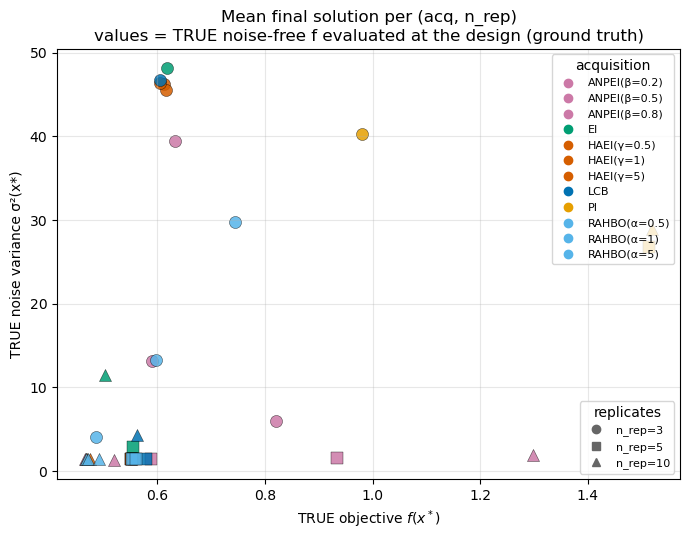

In [3]:
which = "study_v2"        # "study_v2" | "study_v2_gp" | "study_v2_cat"
s = studies[which]
s.plot_objective_variance(is_ground_truth=True)        # aggregated — consistent with the heatmap

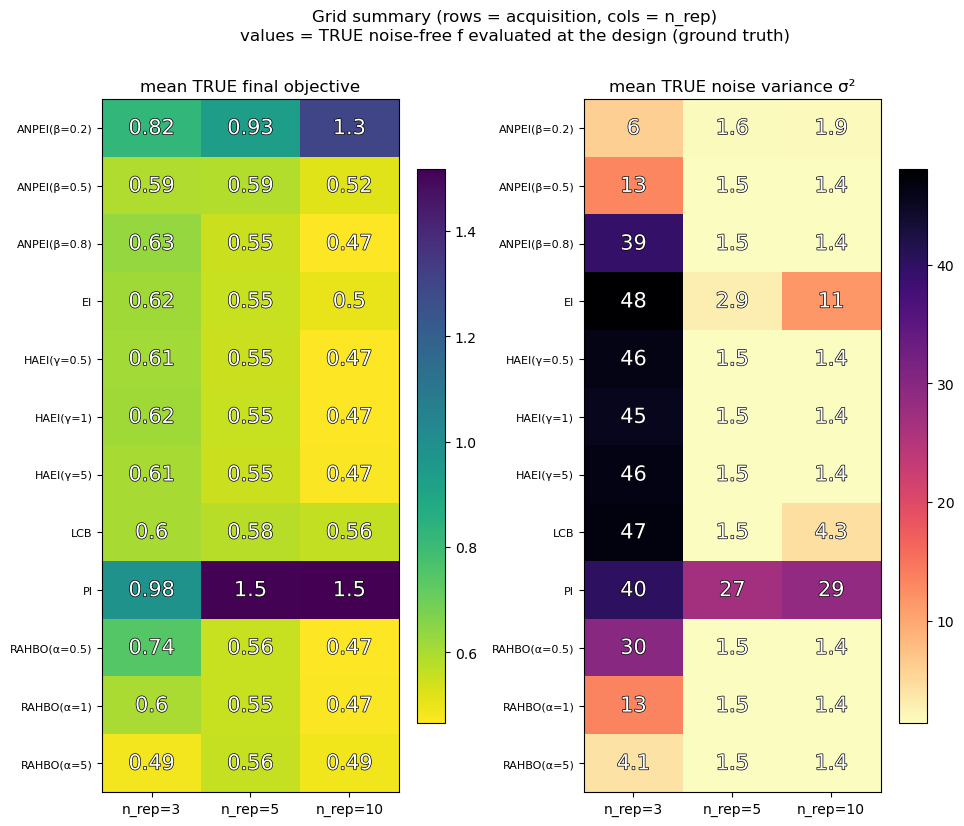

In [4]:
s.plot_summary_heatmaps(is_ground_truth=True)

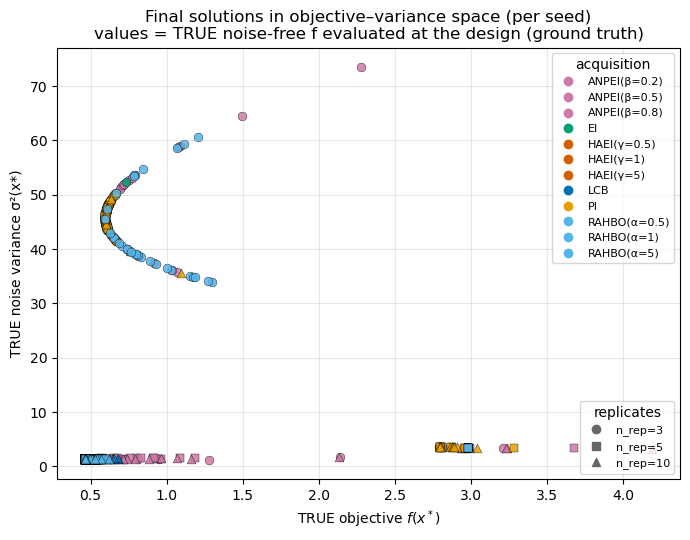

In [5]:
s.plot_objective_variance(is_ground_truth=True, aggregate=False)   # per-seed cloud (wider σ² spread)

## Combined summary heatmaps — all three studies, shared colour ranges
Objective panels (top) share ONE colour range; variance panels (bottom) share another, so the
three studies are directly comparable cell-by-cell. Saved to `plots_study/summary_heatmaps_3studies.png`.

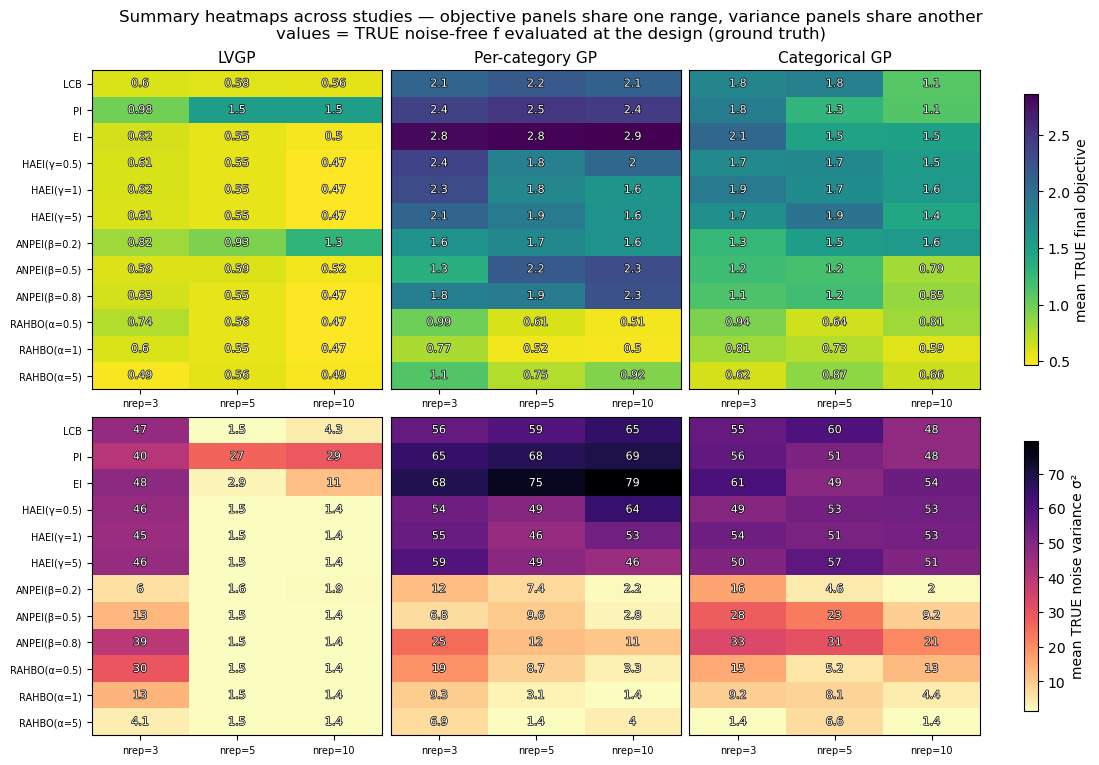

In [6]:
from utils import compare_summary_heatmaps
present = [(studies[d], lab) for d, lab in STUDIES if studies[d].runs]
fig = compare_summary_heatmaps(present, is_ground_truth=True)
fig.savefig("plots_study/summary_heatmaps_3studies.png", dpi=140, bbox_inches="tight")
fig